In [1]:
# !pip install keras==2.3.1
# !pip install tensorflow==2.2.0
# !pip install protobuf==3.19.6                                                                
# !pip install opencv-python==4.4.0.46
# !pip install scikit-learn
# !pip install matplotlib
# !pip install numpy

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
from keras.utils.np_utils import to_categorical
from keras.layers import MaxPooling2D
from keras.layers import Dense,Dropout,Activation,Flatten
from keras.layers import Convolution2D
from keras.models import Sequential
from keras.models import model_from_json

Using TensorFlow backend.


In [4]:
IMG_SIZE=128

In [5]:
import os

In [6]:
def loaddataset(basepath):
  X,Y=[],[]
  for label, folder in enumerate(['no','yes']):
    folder_path=os.path.join(basepath,folder)
    for file in os.listdir(folder_path):
      path=os.path.join(folder_path,file)
      print(path)
      img=cv2.imread(path,0)
      if img is None:
        continue
      #img=cv2.resize(img,IMG_SIZE,IMG_SIZE)
      #img=cv2.reshape(img,IMG_SIZE,IMG_SIZE,1)
      img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
      img = img.reshape(IMG_SIZE, IMG_SIZE, 1)

      X.append(img)
      Y.append(label)
  return np.array(X), np.array(Y)

In [8]:
#sr="dataset"
#
#
sr="dataset"
X,Y = loaddataset(sr)

dataset\no\1 no.jpeg
dataset\no\10 no.jpg
dataset\no\11 no.jpg
dataset\no\12 no.jpg
dataset\no\13 no.jpg
dataset\no\14 no.jpg
dataset\no\15 no.jpg
dataset\no\17 no.jpg
dataset\no\18 no.jpg
dataset\no\19 no.jpg
dataset\no\2 no.jpeg
dataset\no\20 no.jpg
dataset\no\21 no.jpg
dataset\no\22 no.jpg
dataset\no\23 no.jpg
dataset\no\24 no.jpg
dataset\no\25 no.jpg
dataset\no\26 no.jpg
dataset\no\27 no.jpg
dataset\no\28 no.jpg
dataset\no\29 no.jpg
dataset\no\3 no.jpg
dataset\no\30 no.jpg
dataset\no\31 no.jpg
dataset\no\32 no.jpg
dataset\no\33 no.jpg
dataset\no\34 no.jpg
dataset\no\35 no.jpg
dataset\no\36 no.jpg
dataset\no\37 no.jpg
dataset\no\38 no.jpg
dataset\no\39 no.jpg
dataset\no\4 no.jpg
dataset\no\40 no.jpg
dataset\no\41 no.jpg
dataset\no\42 no.jpg
dataset\no\43 no.jpg
dataset\no\44no.jpg
dataset\no\45 no.jpg
dataset\no\46 no.jpg
dataset\no\47 no.jpg
dataset\no\48 no.jpeg
dataset\no\49 no.jpg
dataset\no\5 no.jpg
dataset\no\50 no.jpg
dataset\no\6 no.jpg
dataset\no\7 no.jpg
dataset\no\8 no.jp

In [9]:
print("Total images loaded:", len(X))

Total images loaded: 253


In [10]:
X = X.astype("float")/255.0
Y = to_categorical(Y)
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [11]:
model = Sequential()
model.add(Convolution2D(32, (3, 3), input_shape=(128, 128, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Convolution2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(2, activation='softmax'))

In [12]:
import pickle

In [13]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])
model.summary()
hist = model.fit(X_train, y_train, batch_size=16, epochs=10, validation_split=0.2, shuffle=True, verbose=2)
os.makedirs('Model', exist_ok=True)
model.save_weights('Model/model_weights.h5')



Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 126, 126, 32)      320       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 63, 63, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 61, 61, 32)        9248      
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 30, 30, 32)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 28800)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               3686528   
_________________________________________________________________
dense_2 (Dense)              (None, 2)                

In [14]:
import pickle

In [15]:
model_json = model.to_json()
with open("Model/model.json","w")  as json_file:
    json_file.write(model_json)

f=open("Model/histoy.pckl","wb")
pickle.dump(hist.history, f)
f.close()

In [16]:
loss,  accuracy = model.evaluate(X_test, y_test, verbose=0)
print(loss)
print(accuracy)

0.3820570250790493
0.9411764740943909


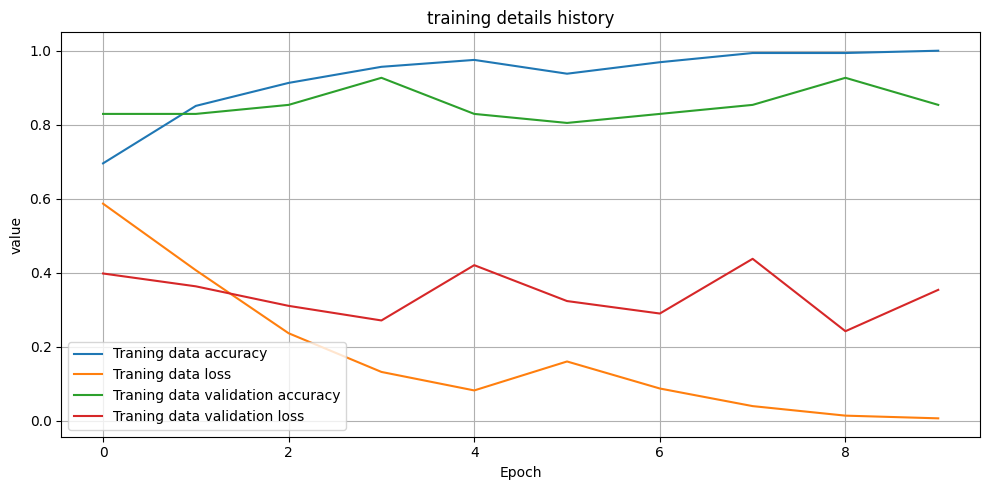

In [17]:
#call matplotlib graphs to draw accuracy performance value
acc=hist.history['accuracy']
los=hist.history['loss']

val_acc=hist.history['val_accuracy']
val_los=hist.history['val_loss']

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(acc,label="Traning data accuracy")
plt.plot(los,label="Traning data loss")
plt.plot(val_acc,label="Traning data validation accuracy")
plt.plot(val_los,label="Traning data validation loss")

#x and y axis.
plt.xlabel('Epoch')
plt.ylabel('value')

plt.title('training details history')
#which call the matplotlib
plt.legend()
plt.grid(True)
#structure of the frame
plt.tight_layout()
plt.show()

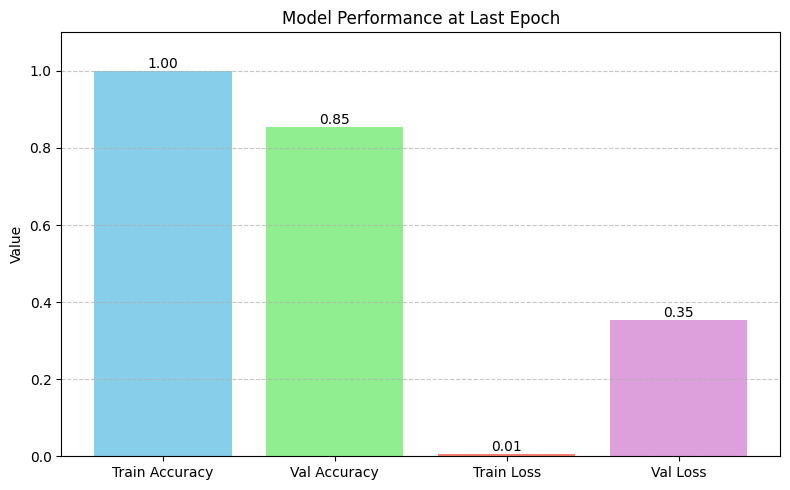

In [18]:
import matplotlib.pyplot as plt

# Get the last epoch's metrics
last_acc = hist.history['accuracy'][-1]
last_val_acc = hist.history['val_accuracy'][-1]
last_loss = hist.history['loss'][-1]
last_val_loss = hist.history['val_loss'][-1]

# Labels and values for the bar chart
labels = ['Train Accuracy', 'Val Accuracy', 'Train Loss', 'Val Loss']
values = [last_acc, last_val_acc, last_loss, last_val_loss]
colors = ['skyblue', 'lightgreen', 'salmon', 'plum']

# Plotting
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors)

# Annotate bars with values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}',
             ha='center', va='bottom', fontsize=10)

# Titles and labels
plt.title('Model Performance at Last Epoch')
plt.ylabel('Value')
plt.ylim(0, max(values) + 0.1)  # Adjust Y-axis if needed
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split


In [21]:
print("Train shape:", X_train.shape)
print(" Test shape:", X_test.shape)
print("Labels (train):", np.unique(X_train, return_counts=True))

Train shape: (202, 128, 128, 1)
 Test shape: (51, 128, 128, 1)
Labels (train): (array([0.        , 0.00392157, 0.00784314, 0.01176471, 0.01568627,
       0.01960784, 0.02352941, 0.02745098, 0.03137255, 0.03529412,
       0.03921569, 0.04313725, 0.04705882, 0.05098039, 0.05490196,
       0.05882353, 0.0627451 , 0.06666667, 0.07058824, 0.0745098 ,
       0.07843137, 0.08235294, 0.08627451, 0.09019608, 0.09411765,
       0.09803922, 0.10196078, 0.10588235, 0.10980392, 0.11372549,
       0.11764706, 0.12156863, 0.1254902 , 0.12941176, 0.13333333,
       0.1372549 , 0.14117647, 0.14509804, 0.14901961, 0.15294118,
       0.15686275, 0.16078431, 0.16470588, 0.16862745, 0.17254902,
       0.17647059, 0.18039216, 0.18431373, 0.18823529, 0.19215686,
       0.19607843, 0.2       , 0.20392157, 0.20784314, 0.21176471,
       0.21568627, 0.21960784, 0.22352941, 0.22745098, 0.23137255,
       0.23529412, 0.23921569, 0.24313725, 0.24705882, 0.25098039,
       0.25490196, 0.25882353, 0.2627451 , 0.2666

In [1]:
import cv2
import numpy as np
from keras.models import model_from_json

Using TensorFlow backend.


In [2]:
jsonmodels = open("Model/model.json", 'r')
loaddata = jsonmodels.read()
jsonmodels.close()

In [15]:
model = model_from_json(loaddata)
model.load_weights("Model/model_weights.h5")
print("[INFO] Loaded model from disk.")

[INFO] Loaded model from disk.


In [8]:
disease = ['No tumor detected', 'tumor detected']

filename = "C://Users//kunch//OneDrive//Desktop//Tumor//BainTumor//dataset//no//1 no.jpeg"
img = cv2.imread(filename, 0)
img = cv2.resize(img, (128, 128))
img = img.reshape(1, 128, 128, 1)
img = img.astype('float32') / 255.0

In [13]:
result = model.predict(img)
prediction = disease[np.argmax(result)]
print("Prediction:", prediction)


Prediction: tumor detected


In [14]:
predicts = model.predict(img)
cls = np.argmax(predicts)
print(f"[INFO] Prediction Probabilities: {predicts}")
print(f"[INFO] Classified as :{disease[cls]}")


[INFO] Prediction Probabilities: [[0.49151245 0.5084875 ]]
[INFO] Classified as :tumor detected
